# 01 · Weather as a price driver

**Research question 1:** How, and by how much, does the weather change the Lithuanian day-ahead electricity price?

This notebook tests hypotheses H1–H5 on hourly data for January 2023 – August 2026
(the `lt_hourly` view built by `src/build_db.py`).

| Hypothesis | Statement |
|---|---|
| H1 | Stronger wind in the Baltic states lowers the Lithuanian day-ahead price, holding demand, solar, gas, Nordic hydro and calendar effects fixed. |
| H2 | The effect of Baltic wind on the price has grown from 2023 to 2026 as installed wind capacity increased. |
| H3 | Nordic and Continental wind also lower the Lithuanian price; without them the Baltic wind effect is overstated. |
| H4 | Wind lowers the price more when natural gas is expensive, because it displaces gas-fired plants. |
| H5 | More water than normal in Nordic hydro reservoirs lowers the Lithuanian price. |

**Identification strategy.** Wind is measured with ERA5 weather indices, not with actual generation:
the weather is not affected by the electricity market, while actual wind output is (wind farms are
curtailed when prices are negative). Common causes of wind and price (season, time of day, demand,
gas, hydro, regional weather) are controlled for. Mediators (imports, neighbouring prices, actual
generation) are deliberately left out, because controlling for them would block part of the effect.

**Robustness checks:** coefficient stability, a placebo test with future wind, a dose–response check,
a pre/post-synchronisation split, an instrumental-variable (2SLS) estimate, a median regression,
data checks, clustered standard errors for slow variables and H2 on comparable months.

**Follow-up analyses (sections 8.10–8.13):** a finer split of regional wind, H2 with indicators for the
2025 structural breaks (with a check that the Estlink 2 effect is not a winter pattern), the effect per
100 MW of wind output by year (2SLS), H4 in tight hours, and an out-of-sample check (section 8.14).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

HAC = {"cov_type": "HAC", "cov_kwds": {"maxlags": 48}}  # errors correlated over up to 48 hours
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

con = duckdb.connect(str(ROOT / "data" / "lt_power.duckdb"), read_only=True)
df = con.sql("SELECT * FROM lt_hourly ORDER BY ts_utc").df()
con.close()
print(f"{len(df):,} hours from {df['ts_local'].min()} to {df['ts_local'].max()}")

32,135 hours from 2023-01-01 00:00:00 to 2026-08-31 23:00:00


## 1. Variables and units

Units are chosen so that every coefficient reads as "€/MWh change in the hourly price".

| Variable | Meaning | Unit |
|---|---|---|
| `price` | Lithuanian day-ahead price | €/MWh |
| `wind_baltic` | Mean ERA5 wind capacity factor of Lithuania, Latvia and Estonia | % of capacity (0–100) |
| `wind_nordic` | The same for Sweden, Finland, Norway and Denmark | % of capacity |
| `wind_continental` | The same for Poland and Germany | % of capacity |
| `solar_rad` | ERA5 solar radiation in Lithuania | 100 W/m² |
| `load_fc_gw` | Day-ahead load forecast for Lithuania | GW |
| `gas` | Last TTF front-month close before the delivery day | €/MWh |
| `hydro_twh` | Nordic reservoir content minus the 2015–2022 normal for that week | TWh |

Used only in the robustness checks and follow-ups:

| Variable | Meaning | Unit |
|---|---|---|
| `wind_lt`, `wind_lv_ee` | ERA5 wind capacity factor of Lithuania, and of Latvia and Estonia (2SLS) | % of capacity |
| `wind_mw_100` | Actual Lithuanian wind output (2SLS) | 100 MW |
| `wind_se_fi`, `wind_no_dk`, `wind_no` | Finer split of the Nordic index (section 8.10) | % of capacity |
| `wind_continental_dk` | Poland, Germany and Denmark (section 8.10) | % of capacity |

Fixed effects: hour of day, day of week, month and year (local Lithuanian time).

In [2]:
df["year"] = df["ts_local"].dt.year
df["wind_lt"] = df["wind_cf_lt"] * 100
df["wind_lv_ee"] = df[["wind_cf_lv", "wind_cf_ee"]].mean(axis=1) * 100
df["wind_baltic"] = df[["wind_cf_lt", "wind_cf_lv", "wind_cf_ee"]].mean(axis=1) * 100
df["wind_nordic"] = df[["wind_cf_se", "wind_cf_fi", "wind_cf_no", "wind_cf_dk"]].mean(axis=1) * 100
df["wind_continental"] = df[["wind_cf_pl", "wind_cf_de"]].mean(axis=1) * 100
df["wind_se_fi"] = df[["wind_cf_se", "wind_cf_fi"]].mean(axis=1) * 100            # directly connected Nordics
df["wind_no_dk"] = df[["wind_cf_no", "wind_cf_dk"]].mean(axis=1) * 100
df["wind_no"] = df["wind_cf_no"] * 100
df["wind_continental_dk"] = df[["wind_cf_pl", "wind_cf_de", "wind_cf_dk"]].mean(axis=1) * 100
df["solar_rad"] = df["solar_rad_lt_wm2"] / 100
df["load_fc_gw"] = df["load_forecast_mw"] / 1000
df["gas"] = df["ttf_eur_mwh"]
df["hydro_twh"] = df["nordic_hydro_deviation_gwh"] / 1000
df["wind_mw_100"] = df["wind_mw"] / 100                       # actual wind output, per 100 MW
df["wind_baltic_lead168"] = df["wind_baltic"].shift(-168)     # wind one week later (placebo)

FE = "C(hour_local) + C(weekday) + C(month_local) + C(year)"
CONTROLS = f"solar_rad + load_fc_gw + gas + hydro_twh + {FE}"
MODEL_COLS = ["price", "wind_baltic", "wind_nordic", "wind_continental", "solar_rad",
              "load_fc_gw", "gas", "hydro_twh", "hour_local", "weekday", "month_local", "year"]

d = df.dropna(subset=MODEL_COLS).copy()
print(f"Model sample: {len(d):,} hours ({len(df) - len(d)} dropped because of missing values)")
d[["price", "wind_baltic", "wind_nordic", "wind_continental", "solar_rad", "load_fc_gw", "gas", "hydro_twh"]].describe().round(2)

Model sample: 31,958 hours (177 dropped because of missing values)


,price,wind_baltic,wind_nordic,wind_continental,solar_rad,load_fc_gw,gas,hydro_twh
count,31958.00,31958.00,31958.00,31958.00,31958.00,31958.00,31958.00,31958.00
mean,90.82,20.54,19.39,17.22,1.24,1.37,39.13,2.40
std,68.67,20.22,13.19,16.32,1.89,0.28,9.70,8.18
min,-56.55,0.00,0.18,0.02,0.00,0.52,22.93,-11.74
25%,42.86,5.68,9.15,5.96,0.00,1.16,32.14,-3.32
50%,86.79,13.56,16.14,12.01,0.08,1.34,36.45,1.77
75%,122.95,28.58,26.97,22.76,1.94,1.53,45.21,6.77
max,1478.91,100.00,87.26,99.34,8.54,2.60,76.32,25.61


In [3]:
def effect(model, name, scale=1.0):
    # Coefficient of one variable with its 95% confidence interval and p-value, times `scale`.
    ci = model.conf_int().loc[name] * scale
    return pd.Series({
        "effect": model.params[name] * scale,
        "ci_low": ci.min(),
        "ci_high": ci.max(),
        "p_value": model.pvalues[name],
    })


def contrast(model, weights):
    # t-test of a linear combination of coefficients, e.g. {"a": 1, "b": -1} for a - b.
    r = np.zeros(len(model.params))
    for name, w in weights.items():
        r[model.params.index.get_loc(name)] = w
    t = model.t_test(r)
    lo, hi = np.asarray(t.conf_int()).ravel()
    return pd.Series({"effect": float(np.asarray(t.effect).ravel()[0]), "ci_low": lo, "ci_high": hi,
                      "p_value": float(np.asarray(t.pvalue).ravel()[0])})


def fmt_p(p):
    # p-value as text. A p-value is never exactly 0, so very small values are shown as an upper bound.
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def show(table, decimals=3):
    """Round a results table for display. p-values below 0.001 are written as <0.001, since they are never exactly 0."""
    out = table.round(decimals)
    if "p_value" in out.columns:
        out["p_value"] = table["p_value"].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
    return out

## 2. How correlated is the wind across regions?

Weather systems cover hundreds of kilometres, so the regional wind indices move together.
This matters twice: it is the reason why regional wind must be controlled for (H3), and it tells us
whether Lithuania can be separated statistically from Latvia and Estonia. If the correlation between
Lithuania and its neighbours is above ~0.9, their separate coefficients would be unstable, so the
model uses the Baltic mean.

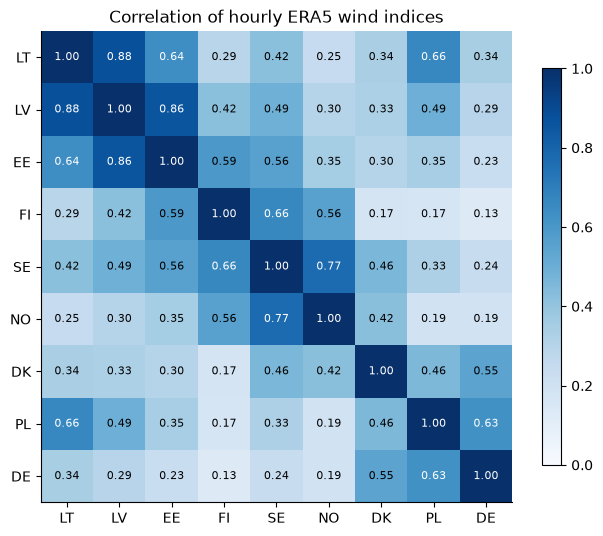

In [4]:
regions = ["lt", "lv", "ee", "fi", "se", "no", "dk", "pl", "de"]
corr = df[[f"wind_cf_{r}" for r in regions]].corr()
corr.index = corr.columns = [r.upper() for r in regions]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(regions)), corr.columns)
ax.set_yticks(range(len(regions)), corr.index)
for i in range(len(regions)):
    for j in range(len(regions)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if corr.iloc[i, j] > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation of hourly ERA5 wind indices")
fig.tight_layout()
fig.savefig(FIG / "q1_wind_correlation.png", dpi=150)
plt.show()

## 3. The supply curve: price against residual load

Residual load is demand minus wind and solar output, i.e. what the remaining power plants and
imports must cover. Plotting the price against it shows the shape of the merit order for each year.
This chart is descriptive only: it uses actual generation, which is itself affected by prices.

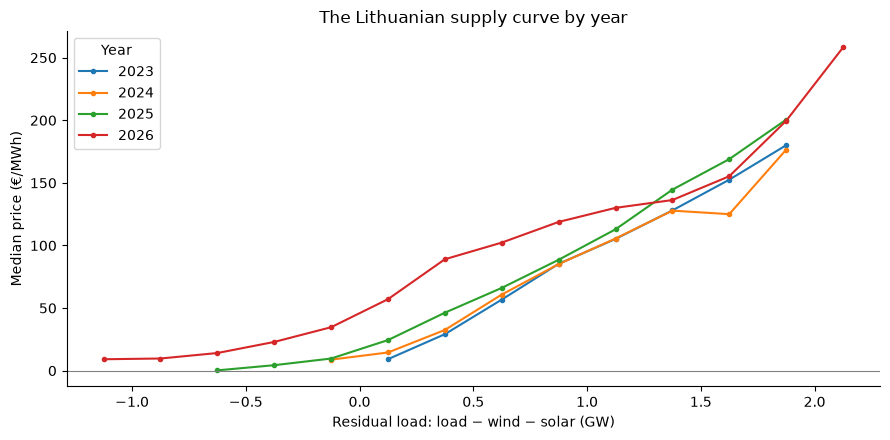

In [5]:
d["residual_gw"] = d["residual_load_mw"] / 1000
edges = np.arange(np.floor(d["residual_gw"].min() * 4) / 4, d["residual_gw"].max() + 0.25, 0.25)
d["residual_bin"] = pd.cut(d["residual_gw"], edges)
curve = (d.groupby(["year", "residual_bin"], observed=True)["price"]
           .agg(["median", "count"]).reset_index())
curve = curve[curve["count"] >= 30]                     # skip bins with too few hours
curve["x"] = curve["residual_bin"].apply(lambda b: b.mid)

fig, ax = plt.subplots()
for year, g in curve.groupby("year"):
    ax.plot(g["x"], g["median"], marker="o", ms=3, label=str(year))
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Residual load: load − wind − solar (GW)")
ax.set_ylabel("Median price (€/MWh)")
ax.set_title("The Lithuanian supply curve by year")
ax.legend(title="Year")
fig.tight_layout()
fig.savefig(FIG / "q1_supply_curve.png", dpi=150)
plt.show()

## 4. H1 and H5 — the main regression

`price = β·wind_baltic + regional wind + solar + load forecast + gas + hydro + fixed effects + error`

Standard errors are Newey–West (HAC) with 48 lags, because errors in neighbouring hours are correlated.
H1 is tested with the full model (including regional wind); H5 is the hydro coefficient of the same model.

A p-value is never exactly zero, so values below 0.001 are shown as <0.001. With about 32,000 hours even modest effects are highly significant, so the size of an effect and its confidence interval matter more than its p-value.

In [6]:
m_base = smf.ols(f"price ~ wind_baltic + {CONTROLS}", data=d).fit(**HAC)
m_full = smf.ols(f"price ~ wind_baltic + wind_nordic + wind_continental + {CONTROLS}", data=d).fit(**HAC)

effects = pd.DataFrame({
    "+10 pp Baltic wind": effect(m_full, "wind_baltic", 10),
    "+10 pp Nordic wind": effect(m_full, "wind_nordic", 10),
    "+10 pp Continental wind": effect(m_full, "wind_continental", 10),
    "+100 W/m² solar radiation": effect(m_full, "solar_rad"),
    "+100 MW load forecast": effect(m_full, "load_fc_gw", 0.1),
    "+10 €/MWh gas": effect(m_full, "gas", 10),
    "+10 TWh Nordic hydro vs normal": effect(m_full, "hydro_twh", 10),
}).T
print(f"R² = {m_full.rsquared:.3f}, hours = {int(m_full.nobs):,}")
show(effects)

R² = 0.529, hours = 31,958


,effect,ci_low,ci_high,p_value
+10 pp Baltic wind,-7.608,-8.489,-6.726,<0.001
+10 pp Nordic wind,-7.446,-8.996,-5.897,<0.001
+10 pp Continental wind,-5.340,-6.502,-4.179,<0.001
+100 W/m² solar radiation,-13.021,-14.376,-11.665,<0.001
+100 MW load forecast,12.264,10.462,14.066,<0.001
+10 €/MWh gas,5.315,3.023,7.608,<0.001
+10 TWh Nordic hydro vs normal,4.995,1.410,8.579,0.006


### 4.1 How big is a typical move?
The units above are not equally common: +10 pp is half a standard deviation of Baltic wind, while the load
forecast rarely moves by more than a few hundred MW. To compare the drivers fairly, each effect is scaled by
one standard deviation — both of the raw variable and of the variation left after the controls (fixed effects
and the other drivers), which is the variation the coefficient is actually estimated from.

In [7]:
drivers = ["wind_baltic", "wind_nordic", "wind_continental", "solar_rad", "load_fc_gw", "gas", "hydro_twh"]
rows = {}
for v in drivers:
    others = " + ".join(x for x in drivers if x != v)
    sd_after = smf.ols(f"{v} ~ {others} + {FE}", data=d).fit().resid.std()
    rows[v] = {"raw SD": d[v].std(), "SD after controls": sd_after,
               "effect per raw SD (€/MWh)": m_full.params[v] * d[v].std(),
               "effect per SD after controls (€/MWh)": m_full.params[v] * sd_after}
typical = pd.DataFrame(rows).T
typical.round(2)

,raw SD,SD after controls,effect per raw SD (€/MWh),effect per SD after controls (€/MWh)
wind_baltic,20.22,16.19,-15.38,-12.32
wind_nordic,13.19,10.32,-9.82,-7.68
wind_continental,16.32,12.92,-8.71,-6.90
solar_rad,1.89,0.95,-24.55,-12.39
load_fc_gw,0.28,0.13,33.87,15.77
gas,9.70,7.31,5.15,3.89
hydro_twh,8.18,5.88,4.08,2.94


## 5. H3 — does regional wind matter?

Compare the Baltic wind coefficient without and with Nordic and Continental wind.
If weather systems are regional, the Baltic coefficient without regional wind also picks up
the effect of wind elsewhere and is too large in absolute value.

The last row answers a different question: what happens when all three regions become 10 pp windier
at the same time (the sum of the three coefficients, with its confidence interval).

In [8]:
region_wide = contrast(m_full, {"wind_baltic": 10, "wind_nordic": 10, "wind_continental": 10})
h3 = pd.DataFrame({
    "Baltic wind, model without regional wind": effect(m_base, "wind_baltic", 10),
    "Baltic wind, model with regional wind": effect(m_full, "wind_baltic", 10),
    "Nordic wind": effect(m_full, "wind_nordic", 10),
    "Continental wind": effect(m_full, "wind_continental", 10),
    "All three regions +10 pp at once": region_wide,
}).T
show(h3)

,effect,ci_low,ci_high,p_value
"Baltic wind, model without regional wind",-11.378,-12.330,-10.425,<0.001
"Baltic wind, model with regional wind",-7.608,-8.489,-6.726,<0.001
Nordic wind,-7.446,-8.996,-5.897,<0.001
Continental wind,-5.340,-6.502,-4.179,<0.001
All three regions +10 pp at once,-20.394,-22.167,-18.622,<0.001


## 6. H2 — has the wind effect grown over the years?

The Baltic wind coefficient is estimated separately for each year (interaction of wind with year).

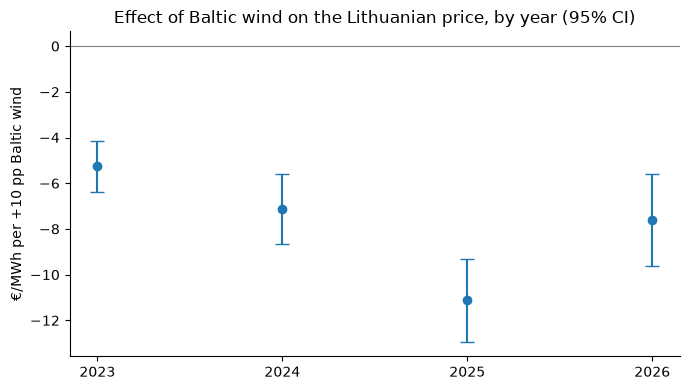

Change 2023 → 2026: -2.34 €/MWh per +10 pp, p = 0.040


,effect,ci_low,ci_high,p_value
2023,-5.263,-6.373,-4.152,<0.001
2024,-7.118,-8.649,-5.588,<0.001
2025,-11.121,-12.931,-9.311,<0.001
2026,-7.598,-9.621,-5.576,<0.001


In [9]:
m_year = smf.ols(f"price ~ wind_baltic:C(year) + wind_nordic + wind_continental + {CONTROLS}",
                 data=d).fit(**HAC)
years = sorted(d["year"].unique())
by_year = pd.DataFrame({y: effect(m_year, f"wind_baltic:C(year)[{y}]", 10) for y in years}).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(by_year.index.astype(str), by_year["effect"],
            yerr=[by_year["effect"] - by_year["ci_low"], by_year["ci_high"] - by_year["effect"]],
            fmt="o", capsize=5)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("€/MWh per +10 pp Baltic wind")
ax.set_title("Effect of Baltic wind on the Lithuanian price, by year (95% CI)")
fig.tight_layout()
fig.savefig(FIG / "q1_wind_effect_by_year.png", dpi=150)
plt.show()

h2_test = contrast(m_year, {f"wind_baltic:C(year)[{years[-1]}]": 10, f"wind_baltic:C(year)[{years[0]}]": -10})
print(f"Change {years[0]} → {years[-1]}: {h2_test['effect']:.2f} €/MWh per +10 pp, {fmt_p(h2_test['p_value'])}")
show(by_year)

## 7. H4 — does wind lower the price more when gas is expensive?

Wind and gas are centred on their means, so the interaction coefficient reads as
"how much the effect of +10 pp wind changes per +1 €/MWh of gas".

**Important:** the wind effect is allowed to differ by year (as in H2). Otherwise two trends would be
mixed up: gas was expensive in 2023, when there was little wind capacity, and cheaper later, when there
was much more. A model without year-specific wind effects would wrongly conclude that wind matters *less*
when gas is expensive. With them, the gas interaction is estimated from gas price changes *within* each year.
The table shows the implied effect of +10 pp wind in the latest year at low, median and high gas prices.

In [10]:
d["wind_baltic_c"] = d["wind_baltic"] - d["wind_baltic"].mean()
d["gas_c"] = d["gas"] - d["gas"].mean()
m_gas = smf.ols(f"price ~ wind_baltic_c:C(year) + wind_baltic_c:gas_c + gas_c + wind_nordic + "
                f"wind_continental + solar_rad + load_fc_gw + hydro_twh + {FE}", data=d).fit(**HAC)

h4_inter = effect(m_gas, "wind_baltic_c:gas_c", 10)
print(f"Interaction: the effect of +10 pp wind changes by {h4_inter['effect']:.3f} €/MWh "
      f"per +1 €/MWh gas ({fmt_p(h4_inter['p_value'])})")

levels = d["gas"].quantile([0.1, 0.5, 0.9])
last_year = years[-1]
at_gas = pd.DataFrame({
    f"{last_year}, gas = {g:.0f} €/MWh ({int(q * 100)}th percentile)": contrast(
        m_gas, {f"wind_baltic_c:C(year)[{last_year}]": 10, "wind_baltic_c:gas_c": 10 * (g - d["gas"].mean())})
    for q, g in levels.items()
}).T
show(at_gas)

Interaction: the effect of +10 pp wind changes by -0.036 €/MWh per +1 €/MWh gas (p = 0.386)


,effect,ci_low,ci_high,p_value
"2026, gas = 28 €/MWh (10th percentile)",-6.969,-9.425,-4.513,<0.001
"2026, gas = 36 €/MWh (50th percentile)",-7.266,-9.422,-5.110,<0.001
"2026, gas = 52 €/MWh (90th percentile)",-7.826,-9.943,-5.708,<0.001


## 8. Robustness checks

### 8.1 Coefficient stability
Controls are added one at a time. If the wind coefficient stays in the same range once the main
controls are in, an important omitted variable is less likely.

In [11]:
steps = [
    ("no controls", ""),
    ("+ fixed effects", f" + {FE}"),
    ("+ load forecast", f" + load_fc_gw + {FE}"),
    ("+ gas", f" + load_fc_gw + gas + {FE}"),
    ("+ hydro", f" + load_fc_gw + gas + hydro_twh + {FE}"),
    ("+ solar", f" + load_fc_gw + gas + hydro_twh + solar_rad + {FE}"),
    ("+ regional wind", f" + load_fc_gw + gas + hydro_twh + solar_rad + wind_nordic + wind_continental + {FE}"),
]
stability = pd.DataFrame({
    label: effect(smf.ols(f"price ~ wind_baltic{rhs}", data=d).fit(**HAC), "wind_baltic", 10)
    for label, rhs in steps
}).T
show(stability)

,effect,ci_low,ci_high,p_value
no controls,-9.565,-10.592,-8.538,<0.001
+ fixed effects,-12.106,-13.064,-11.147,<0.001
+ load forecast,-10.679,-11.626,-9.732,<0.001
+ gas,-10.753,-11.693,-9.814,<0.001
+ hydro,-10.819,-11.748,-9.890,<0.001
+ solar,-11.378,-12.330,-10.425,<0.001
+ regional wind,-7.608,-8.489,-6.726,<0.001


### 8.2 Placebo test: wind one week later
Wind that will blow a week later cannot change today's price. If its coefficient is clearly
different from zero, the model is picking up seasonal patterns rather than the effect of wind.

In [12]:
d_pl = d.dropna(subset=["wind_baltic_lead168"])
m_placebo = smf.ols(f"price ~ wind_baltic + wind_baltic_lead168 + wind_nordic + wind_continental + {CONTROLS}",
                    data=d_pl).fit(**HAC)
placebo = pd.DataFrame({
    "Baltic wind now": effect(m_placebo, "wind_baltic", 10),
    "Baltic wind one week later (placebo)": effect(m_placebo, "wind_baltic_lead168", 10),
}).T
show(placebo)

,effect,ci_low,ci_high,p_value
Baltic wind now,-7.561,-8.440,-6.683,<0.001
Baltic wind one week later (placebo),0.741,-0.042,1.524,0.064


### 8.3 Dose–response
Instead of a straight line, the model gets one dummy per decile of Baltic wind (decile 1 = calmest
tenth of hours = reference). If wind causes lower prices, the price should fall step by step.

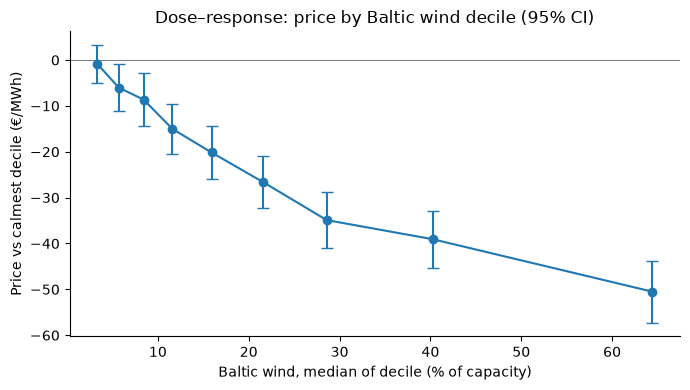

Rank correlation between decile and effect: -1.00 (−1 = perfectly decreasing)


In [13]:
d["wind_decile"] = pd.qcut(d["wind_baltic"], 10, labels=range(1, 11))
m_dose = smf.ols(f"price ~ C(wind_decile) + wind_nordic + wind_continental + {CONTROLS}", data=d).fit(**HAC)
dose = pd.DataFrame({k: effect(m_dose, f"C(wind_decile)[T.{k}]") for k in range(2, 11)}).T
mid = d.groupby("wind_decile", observed=True)["wind_baltic"].median()

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(mid.loc[dose.index], dose["effect"],
            yerr=[dose["effect"] - dose["ci_low"], dose["ci_high"] - dose["effect"]], fmt="o-", capsize=4)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Baltic wind, median of decile (% of capacity)")
ax.set_ylabel("Price vs calmest decile (€/MWh)")
ax.set_title("Dose–response: price by Baltic wind decile (95% CI)")
fig.tight_layout()
fig.savefig(FIG / "q1_dose_response.png", dpi=150)
plt.show()

monotonic = dose["effect"].reset_index(drop=True).corr(pd.Series(range(len(dose))), method="spearman")
print(f"Rank correlation between decile and effect: {monotonic:.2f} (−1 = perfectly decreasing)")

### 8.4 Before and after synchronisation with Continental Europe (9 February 2025)

In [14]:
SYNC = pd.Timestamp("2025-02-09")
periods = {"before synchronisation": d[d["ts_local"] < SYNC], "after synchronisation": d[d["ts_local"] >= SYNC]}
sync = pd.DataFrame({
    name: effect(smf.ols(f"price ~ wind_baltic + wind_nordic + wind_continental + {CONTROLS}", data=part).fit(**HAC),
                 "wind_baltic", 10)
    for name, part in periods.items()
}).T
show(sync)

,effect,ci_low,ci_high,p_value
before synchronisation,-6.050,-7.055,-5.046,<0.001
after synchronisation,-9.296,-10.892,-7.699,<0.001


### 8.5 Instrumental variable (2SLS): the effect of 100 MW of actual wind output
Actual Lithuanian wind output is partly driven by the price (curtailment), so plain OLS on it could be biased.
The ERA5 Lithuanian wind index is used as an instrument. It moves wind output but is not affected by the
price. Latvian/Estonian and regional wind are controlled for, so the instrument affects the price only
through Lithuanian wind output. A first-stage F statistic far above 10 means the instrument is strong.

In [15]:
IV_CONTROLS = f"wind_lv_ee + wind_nordic + wind_continental + {CONTROLS}"
d_iv = d.dropna(subset=["wind_mw_100", "wind_lt", "wind_lv_ee"])

m_ols_mw = smf.ols(f"price ~ wind_mw_100 + {IV_CONTROLS}", data=d_iv).fit(**HAC)
m_iv = IV2SLS.from_formula(f"price ~ 1 + {IV_CONTROLS} + [wind_mw_100 ~ wind_lt]", data=d_iv).fit(
    cov_type="kernel", kernel="bartlett", bandwidth=48)

first_stage_f = m_iv.first_stage.diagnostics.loc["wind_mw_100", "f.stat"]
print(f"First-stage F statistic: {first_stage_f:,.0f}")
iv_table = pd.DataFrame({
    "OLS on actual wind output": effect(m_ols_mw, "wind_mw_100"),
    "2SLS, ERA5 wind as instrument": effect(m_iv, "wind_mw_100"),
}).T
show(iv_table)

First-stage F statistic: 639


,effect,ci_low,ci_high,p_value
OLS on actual wind output,-3.087,-3.724,-2.451,<0.001
"2SLS, ERA5 wind as instrument",-2.784,-3.827,-1.741,<0.001


### 8.6 Median regression
Negative prices and price spikes pull the mean. A median (quantile) regression is less sensitive to them.

In [16]:
m_median = smf.quantreg(f"price ~ wind_baltic + wind_nordic + wind_continental + {CONTROLS}", data=d).fit(
    q=0.5, max_iter=5000)
print(f"Median regression, +10 pp Baltic wind: {m_median.params['wind_baltic'] * 10:.2f} €/MWh "
      f"(OLS: {m_full.params['wind_baltic'] * 10:.2f} €/MWh)")

Median regression, +10 pp Baltic wind: -6.13 €/MWh (OLS: -7.61 €/MWh)


### 8.7 Data checks
Implausible load forecasts (zero, or more than 50 % away from the actual load) are removed in SQL
(`lt_load_hourly`). This cell shows what remains at the extremes and the highest prices of the period.

In [17]:
low, high = d[d["load_fc_gw"] < 0.5], d[d["load_fc_gw"] > 2.3]
print(f"{len(low)} hours with load forecast below 0.5 GW")
print(f"{len(high)} hours with load forecast above 2.3 GW; actual load in those hours: "
      f"median {high['load_mw'].median():,.0f} MW, minimum {high['load_mw'].min():,.0f} MW")
display(d.nsmallest(5, "load_fc_gw")[["ts_local", "load_forecast_mw", "load_mw"]])
display(d.nlargest(5, "price")[["ts_local", "price", "wind_baltic", "load_fc_gw", "load_mw"]])

0 hours with load forecast below 0.5 GW
189 hours with load forecast above 2.3 GW; actual load in those hours: median 2,331 MW, minimum 2,113 MW


,ts_local,load_forecast_mw,load_mw
20174,2025-04-20 15:00:00,518.6950,897.200000
20169,2025-04-20 10:00:00,552.7375,968.985000
20175,2025-04-20 16:00:00,688.9100,935.777500
30396,2026-06-20 13:00:00,717.7350,1232.553173
30397,2026-06-20 14:00:00,718.8100,1169.334717


,ts_local,price,wind_baltic,load_fc_gw,load_mw
8864,2024-01-05 08:00:00,1478.9100,18.273333,1.844000,1921.580
8865,2024-01-05 09:00:00,1251.6700,16.586667,1.885000,2008.890
24247,2025-10-07 08:00:00,1000.0950,1.560000,1.492975,1737.635
24559,2025-10-20 08:00:00,1000.0175,6.923333,1.610650,1851.060
8866,2024-01-05 10:00:00,1000.0000,15.173333,1.901000,2016.140


### 8.8 Standard errors for slow variables
HAC with 48 lags suits hourly variables such as wind. Gas and hydro change over weeks, so their
uncertainty is also checked with errors clustered by week and by month.

In [18]:
d["week_id"] = pd.factorize(d["ts_local"].dt.strftime("%G-%V"))[0]
d["month_id"] = pd.factorize(d["ts_local"].dt.strftime("%Y-%m"))[0]
formula = f"price ~ wind_baltic + wind_nordic + wind_continental + {CONTROLS}"
se_models = {
    "HAC 48 h": m_full,
    "clustered by week": smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["week_id"].to_numpy()}),
    "clustered by month": smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["month_id"].to_numpy()}),
}
se_check = pd.DataFrame({(label, var): effect(m, var, 10)
                         for label, m in se_models.items() for var in ["wind_baltic", "gas", "hydro_twh"]}).T
show(se_check)

effect  ci_low  ci_high p_value
HAC 48 h           wind_baltic  -7.608  -8.489   -6.726  <0.001
                   gas           5.315   3.023    7.608  <0.001
                   hydro_twh     4.995   1.410    8.579   0.006
clustered by week  wind_baltic  -7.608  -8.672   -6.543  <0.001
                   gas           5.315   2.143    8.487   0.001
                   hydro_twh     4.995   0.509    9.480   0.029
clustered by month wind_baltic  -7.608  -9.134   -6.081  <0.001
                   gas           5.315   1.415    9.215   0.008
                   hydro_twh     4.995   0.023    9.966   0.049

### 8.9 H2 on comparable months
2026 only covers January–August, while the other years are complete. Comparing January–August of every
year removes the difference in seasonal composition.

In [19]:
d_ja = d[d["ts_local"].dt.month <= 8]
m_year_ja = smf.ols(f"price ~ wind_baltic:C(year) + wind_nordic + wind_continental + {CONTROLS}",
                    data=d_ja).fit(**HAC)
by_year_ja = pd.DataFrame({y: effect(m_year_ja, f"wind_baltic:C(year)[{y}]", 10) for y in years}).T
steady_growth = by_year_ja["effect"].is_monotonic_decreasing
print(f"Effect grows every year (January-August): {steady_growth}")
show(by_year_ja)

Effect grows every year (January-August): False


,effect,ci_low,ci_high,p_value
2023,-5.324,-6.906,-3.742,<0.001
2024,-3.346,-5.214,-1.478,<0.001
2025,-10.093,-12.099,-8.088,<0.001
2026,-7.410,-9.373,-5.447,<0.001


### 8.10 Splitting the Nordic index
Sweden and Finland are connected to the Baltics directly (NordBalt, Estlink); Norway and Denmark are not.
Variant A splits the Nordic index along that line. Danish wind, however, correlates more with German (0.55)
than with Swedish wind (0.46), so variant B moves Denmark into the Continental group instead.
The model with the lowest AIC/BIC fits the data best.

In [20]:
variants = {
    "main: Nordic = SE, FI, NO, DK": "wind_nordic + wind_continental",
    "A: SE+FI and NO+DK": "wind_se_fi + wind_no_dk + wind_continental",
    "B: SE+FI, NO, Continental = PL, DE, DK": "wind_se_fi + wind_no + wind_continental_dk",
}
split_models = {name: smf.ols(f"price ~ wind_baltic + {rhs} + {CONTROLS}", data=d).fit(**HAC)
                for name, rhs in variants.items()}
split = pd.DataFrame({(name, v): effect(m, v, 10)
                      for name, m in split_models.items()
                      for v in m.params.index if v.startswith("wind_")}).T
split_fit = pd.DataFrame({name: {"R²": m.rsquared, "AIC": m.aic, "BIC": m.bic}
                          for name, m in split_models.items()}).T
display(show(split))
split_fit.round({"R²": 3, "AIC": 1, "BIC": 1})

effect  ci_low  \
main: Nordic = SE, FI, NO, DK          wind_baltic          -7.608  -8.489   
                                       wind_nordic          -7.446  -8.996   
                                       wind_continental     -5.340  -6.502   
A: SE+FI and NO+DK                     wind_baltic          -7.385  -8.256   
                                       wind_se_fi           -4.638  -6.180   
                                       wind_no_dk           -3.145  -4.353   
                                       wind_continental     -5.640  -6.842   
B: SE+FI, NO, Continental = PL, DE, DK wind_baltic          -7.562  -8.495   
                                       wind_se_fi           -4.575  -6.350   
                                       wind_no              -0.992  -3.672   
                                       wind_continental_dk  -6.638  -7.709   

                                                            ci_high p_value  
main: Nordic = SE, FI, NO, DK          wind_baltic           -6.726  <0.001  
                                       wind_nordic           -5.897  <0.001  
                                       wind_continental      -4.179  <0.001  
A: SE+FI and NO+DK                     wind_baltic           -6.514  <0.001  
                                       wind_se_fi            -3.095  <0.001  
                                       wind_no_dk            -1.936  <0.001  
                                       wind_continental      -4.438  <0.001  
B: SE+FI, NO, Continental = PL, DE, DK wind_baltic           -6.629  <0.001  
                                       wind_se_fi            -2.799  <0.001  
                                       wind_no                1.687   0.468  
                                       wind_continental_dk   -5.567  <0.001

,R²,AIC,BIC
"main: Nordic = SE, FI, NO, DK",0.529,337084.7,337511.6
A: SE+FI and NO+DK,0.529,337072.7,337508.0
"B: SE+FI, NO, Continental = PL, DE, DK",0.528,337114.3,337549.6


### 8.11 H2 — structural breaks in 2025
The year-by-year pattern (a jump in 2025, a partial fall-back in 2026) does not look like steady capacity
growth. Three events happened within months of each other:

- **Estlink 2 outage:** the 650 MW Estonia–Finland cable was damaged on 25 December 2024 and returned on
  20 June 2025 [5].
- **Synchronisation with Continental Europe** on 9 February 2025, five days after the Baltic balancing
  capacity market started [3]. The two are too close to separate, so they share one indicator.
- **15-minute day-ahead market** from delivery day 1 October 2025 [6].

The wind effect gets a linear time trend (a proxy for gradual capacity growth) plus a shift for each event.
The level of the price may also shift at each event. The second table shows the implied effect of +10 pp
Baltic wind on a few representative dates. References are listed at the end of the notebook.

In [21]:
T0 = pd.Timestamp("2023-01-01")
ESTLINK_OUT = (pd.Timestamp("2024-12-25"), pd.Timestamp("2025-06-20"))
MTU15 = pd.Timestamp("2025-10-01")

d["trend"] = (d["ts_local"] - T0).dt.days / 365.25
d["estlink2_out"] = d["ts_local"].between(*ESTLINK_OUT, inclusive="left").astype(int)
d["post_sync"] = (d["ts_local"] >= SYNC).astype(int)
d["post_15min"] = (d["ts_local"] >= MTU15).astype(int)

m_breaks = smf.ols(
    "price ~ wind_baltic + wind_baltic:trend + wind_baltic:estlink2_out + wind_baltic:post_sync"
    f" + wind_baltic:post_15min + estlink2_out + post_sync + post_15min + wind_nordic + wind_continental + {CONTROLS}",
    data=d).fit(**HAC)

breaks = pd.DataFrame({
    "Baltic wind on 1 January 2023": effect(m_breaks, "wind_baltic", 10),
    "change per year (trend)": effect(m_breaks, "wind_baltic:trend", 10),
    "extra during Estlink 2 outage": effect(m_breaks, "wind_baltic:estlink2_out", 10),
    "extra after synchronisation": effect(m_breaks, "wind_baltic:post_sync", 10),
    "extra after 15-minute switch": effect(m_breaks, "wind_baltic:post_15min", 10),
}).T
display(show(breaks))


def wind_effect_at(date):
    # Implied effect of +10 pp Baltic wind on a given date, with its confidence interval.
    date = pd.Timestamp(date)
    weights = {
        "wind_baltic": 10,
        "wind_baltic:trend": 10 * (date - T0).days / 365.25,
        "wind_baltic:estlink2_out": 10 * float(ESTLINK_OUT[0] <= date < ESTLINK_OUT[1]),
        "wind_baltic:post_sync": 10 * float(date >= SYNC),
        "wind_baltic:post_15min": 10 * float(date >= MTU15),
    }
    return contrast(m_breaks, {k: w for k, w in weights.items() if w != 0})


dates = {"mid-2023": "2023-07-01", "mid-2024": "2024-07-01", "Jan 2025 (Estlink 2 out)": "2025-01-15",
         "Mar 2025 (outage + synchronised)": "2025-03-15", "Aug 2025 (synchronised)": "2025-08-15",
         "Mar 2026 (synchronised + 15 min)": "2026-03-15"}
pd.DataFrame({label: wind_effect_at(day) for label, day in dates.items()}).T.pipe(show, 2)

,effect,ci_low,ci_high,p_value
Baltic wind on 1 January 2023,-5.023,-6.637,-3.410,<0.001
change per year (trend),-0.573,-1.990,0.843,0.428
extra during Estlink 2 outage,-5.110,-7.892,-2.328,<0.001
extra after synchronisation,-1.277,-4.382,1.828,0.420
extra after 15-minute switch,-1.557,-5.141,2.027,0.394


,effect,ci_low,ci_high,p_value
mid-2023,-5.31,-6.44,-4.18,<0.001
mid-2024,-5.88,-7.15,-4.61,<0.001
Jan 2025 (Estlink 2 out),-11.30,-14.10,-8.51,<0.001
Mar 2025 (outage + synchronised),-12.67,-15.12,-10.23,<0.001
Aug 2025 (synchronised),-7.80,-10.45,-5.16,<0.001
Mar 2026 (synchronised + 15 min),-9.69,-11.75,-7.63,<0.001


#### Robustness: is the Estlink 2 effect just winter?
The outage covered winter and spring. If wind simply moved the price more in those months, the outage
indicator would pick that up. Here every calendar month gets its own wind effect, so the outage is compared
with the same months of the other years.

In [22]:
m_breaks_month = smf.ols(
    "price ~ wind_baltic:C(month_local) + wind_baltic:trend + wind_baltic:estlink2_out + wind_baltic:post_sync"
    f" + wind_baltic:post_15min + estlink2_out + post_sync + post_15min + wind_nordic + wind_continental + {CONTROLS}",
    data=d).fit(**HAC)
pd.DataFrame({
    "8.11 as estimated": effect(m_breaks, "wind_baltic:estlink2_out", 10),
    "with a separate wind effect for every month": effect(m_breaks_month, "wind_baltic:estlink2_out", 10),
}).T.pipe(show)

,effect,ci_low,ci_high,p_value
8.11 as estimated,-5.110,-7.892,-2.328,<0.001
with a separate wind effect for every month,-8.067,-11.503,-4.632,<0.001


### 8.12 H2 — the effect per 100 MW of wind output, by year
The capacity factor hides capacity growth: the same +10 pp means more MW every year. Here actual Lithuanian
wind output (per 100 MW) is instrumented with ERA5 Lithuanian wind separately for each year, controlling for
Latvian/Estonian and regional wind. If the effect per 100 MW falls over time, each additional MW moves the
price less as the fleet grows — the saturation argument in the interpretation of H2.

Change 2023 → 2026: -0.40 €/MWh per 100 MW (p = 0.617); a positive change means a smaller effect per MW


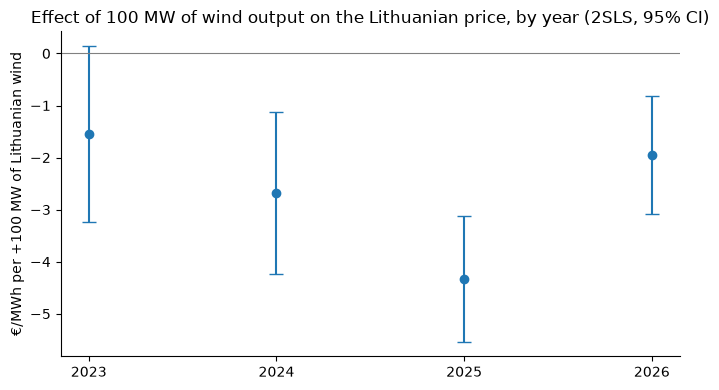

,effect,ci_low,ci_high,p_value,first-stage F
2023,-1.551,-3.244,0.141,0.072,1049.468
2024,-2.681,-4.231,-1.130,<0.001,855.359
2025,-4.324,-5.535,-3.114,<0.001,432.761
2026,-1.950,-3.081,-0.819,<0.001,298.129


In [23]:
from scipy import stats

d_iv_year = d.dropna(subset=["wind_mw_100", "wind_lt", "wind_lv_ee"]).copy()
for y in years:
    d_iv_year[f"wind_mw_100_{y}"] = d_iv_year["wind_mw_100"] * (d_iv_year["year"] == y)
    d_iv_year[f"wind_lt_{y}"] = d_iv_year["wind_lt"] * (d_iv_year["year"] == y)
endog = " + ".join(f"wind_mw_100_{y}" for y in years)
instruments = " + ".join(f"wind_lt_{y}" for y in years)
m_iv_year = IV2SLS.from_formula(f"price ~ 1 + {IV_CONTROLS} + [{endog} ~ {instruments}]", data=d_iv_year).fit(
    cov_type="kernel", kernel="bartlett", bandwidth=48)

per_mw = pd.DataFrame({y: effect(m_iv_year, f"wind_mw_100_{y}") for y in years}).T
per_mw["first-stage F"] = [m_iv_year.first_stage.diagnostics.loc[f"wind_mw_100_{y}", "f.stat"] for y in years]

first, last = f"wind_mw_100_{years[0]}", f"wind_mw_100_{years[-1]}"
b, V = m_iv_year.params, m_iv_year.cov
diff_mw = b[last] - b[first]
p_mw = 2 * (1 - stats.norm.cdf(abs(diff_mw / np.sqrt(V.loc[last, last] + V.loc[first, first] - 2 * V.loc[last, first]))))
print(f"Change {years[0]} → {years[-1]}: {diff_mw:+.2f} €/MWh per 100 MW ({fmt_p(p_mw)}); "
      "a positive change means a smaller effect per MW")

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(per_mw.index.astype(str), per_mw["effect"],
            yerr=[per_mw["effect"] - per_mw["ci_low"], per_mw["ci_high"] - per_mw["effect"]], fmt="o", capsize=5)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("€/MWh per +100 MW of Lithuanian wind")
ax.set_title("Effect of 100 MW of wind output on the Lithuanian price, by year (2SLS, 95% CI)")
fig.tight_layout()
fig.savefig(FIG / "q1_effect_per_100mw_by_year.png", dpi=150)
plt.show()
show(per_mw)

### 8.13 H4 in tight hours
Gas should matter mainly when the system is tight, on the steep part of the supply curve. Tightness must be
measured **exogenously**: actual residual load contains actual wind output, which the price itself affects
(curtailment), so it cannot be used to select hours. Tight hours are therefore those where the day-ahead load
forecast is in the top 30 % of its year. The H4 model is estimated separately for tight and other hours, with
standard errors clustered by month (the subsamples are not continuous in time, so HAC is less suitable).
The differences between tight and other hours are tested from the two estimates (independent subsamples).

In [24]:
d["tight"] = d["load_fc_gw"] >= d.groupby("year")["load_fc_gw"].transform(lambda s: s.quantile(0.7))
h4_formula = (f"price ~ wind_baltic_c:C(year) + wind_baltic_c:gas_c + gas_c + wind_nordic + "
              f"wind_continental + solar_rad + load_fc_gw + hydro_twh + {FE}")
pooled_formula = f"price ~ wind_baltic + wind_nordic + wind_continental + {CONTROLS}"

tight_rows = {}
for name, part in {"tight hours": d[d["tight"]], "other hours": d[~d["tight"]]}.items():
    cluster = {"cov_type": "cluster", "cov_kwds": {"groups": part["month_id"].to_numpy()}}
    m_h4 = smf.ols(h4_formula, data=part).fit(**cluster)
    m_pool = smf.ols(pooled_formula, data=part).fit(**cluster)
    tight_rows[(name, "+10 pp Baltic wind")] = effect(m_pool, "wind_baltic", 10)
    tight_rows[(name, "wind × gas interaction")] = effect(m_h4, "wind_baltic_c:gas_c", 10)
tight_table = pd.DataFrame(tight_rows).T

se = lambda r: (r["ci_high"] - r["ci_low"]) / (2 * 1.96)


def tight_vs_other(row):
    """Difference tight − other for one row of tight_table, with an approximate p-value."""
    a, c = tight_table.loc[("tight hours", row)], tight_table.loc[("other hours", row)]
    diff = a["effect"] - c["effect"]
    return diff, 2 * (1 - stats.norm.cdf(abs(diff) / np.sqrt(se(a) ** 2 + se(c) ** 2)))


wind_diff, p_wind_diff = tight_vs_other("+10 pp Baltic wind")
inter_diff, p_tight_diff = tight_vs_other("wind × gas interaction")
print(f"Hours: {int(d['tight'].sum()):,} tight, {int((~d['tight']).sum()):,} other")
print(f"Difference in the wind effect, tight − other: {wind_diff:+.2f} €/MWh ({fmt_p(p_wind_diff)})")
print(f"Difference in the wind × gas interaction, tight − other: {inter_diff:+.3f} ({fmt_p(p_tight_diff)})")
show(tight_table)

Hours: 9,594 tight, 22,364 other
Difference in the wind effect, tight − other: -4.01 €/MWh (p = 0.003)
Difference in the wind × gas interaction, tight − other: -0.016 (p = 0.883)


effect  ci_low  ci_high p_value
tight hours +10 pp Baltic wind     -10.204 -12.652   -7.756  <0.001
            wind × gas interaction  -0.041  -0.215    0.134   0.649
other hours +10 pp Baltic wind      -6.192  -7.274   -5.111  <0.001
            wind × gas interaction  -0.025  -0.138    0.089   0.667

### 8.14 Out-of-sample check
The regression explains prices; it is not a forecast. It uses same-hour weather that a trader would not know in
advance, and forecasting is question 3. An out-of-sample test still answers two useful questions: is the model
overfitted, and do the weather variables help explain prices in a period the model has not seen?

The models are fitted on 2023–2025 and applied to January–August 2026. Year effects are left out here, because
the training data contain no 2026 year effect to apply. Three specifications are compared: calendar effects only,
plus demand, gas and hydro, and plus wind and solar. A second check re-estimates the main wind effect leaving out
one year at a time.

In [25]:
FE_NO_YEAR = "C(hour_local) + C(weekday) + C(month_local)"
train, test = d[d["year"] < years[-1]], d[d["year"] == years[-1]]
specs = {
    "calendar only": f"price ~ {FE_NO_YEAR}",
    "+ demand, gas, hydro": f"price ~ load_fc_gw + gas + hydro_twh + {FE_NO_YEAR}",
    "+ wind and solar (full model)": ("price ~ wind_baltic + wind_nordic + wind_continental + solar_rad"
                                      f" + load_fc_gw + gas + hydro_twh + {FE_NO_YEAR}"),
}


def r2(y, y_hat):
    # Share of the variance of y explained by y_hat (can be negative out of sample).
    return 1 - ((y - y_hat) ** 2).sum() / ((y - y.mean()) ** 2).sum()


oos = {}
for name, formula in specs.items():
    m = smf.ols(formula, data=train).fit()
    y_out = m.predict(test)
    oos[name] = {
        "MAE in sample, €/MWh": (train["price"] - m.fittedvalues).abs().mean(),
        "MAE out of sample, €/MWh": (test["price"] - y_out).abs().mean(),
        "R² in sample": m.rsquared,
        "R² out of sample": r2(test["price"], y_out),
    }
oos_table = pd.DataFrame(oos).T
display(oos_table.round(3))

loyo = pd.DataFrame({
    f"without {y}": effect(smf.ols(f"price ~ wind_baltic + wind_nordic + wind_continental + {CONTROLS}",
                                   data=d[d["year"] != y]).fit(**HAC), "wind_baltic", 10)
    for y in years
}).T
show(loyo)

,"MAE in sample, €/MWh","MAE out of sample, €/MWh",R² in sample,R² out of sample
calendar only,40.584,48.939,0.226,0.212
"+ demand, gas, hydro",36.701,40.357,0.328,0.523
+ wind and solar (full model),30.170,34.367,0.493,0.611


,effect,ci_low,ci_high,p_value
without 2023,-9.046,-10.182,-7.910,<0.001
without 2024,-7.553,-8.557,-6.548,<0.001
without 2025,-5.862,-6.793,-4.930,<0.001
without 2026,-7.895,-8.854,-6.935,<0.001


## 9. Summary of H1–H5

A hypothesis is supported when the estimate has the expected sign and p < 0.05. H2 counts as partly
supported when the 2023→2026 change is significant but the effect does not grow every year
(January–August comparison, section 8.9).

In [26]:
def verdict(ok):
    return "supported" if ok else "not supported"

h1 = effect(m_full, "wind_baltic", 10)
h5 = effect(m_full, "hydro_twh", 10)
regional_ok = any((effect(m_full, v)["effect"] < 0) and (effect(m_full, v)["p_value"] < 0.05)
                  for v in ["wind_nordic", "wind_continental"])
smaller = abs(m_full.params["wind_baltic"]) < abs(m_base.params["wind_baltic"])
h5_month = effect(se_models["clustered by month"], "hydro_twh", 10)
h2_significant = h2_test["effect"] < 0 and h2_test["p_value"] < 0.05
h2_verdict = ("supported" if h2_significant and steady_growth
              else "partly supported" if h2_significant else "not supported")

summary = pd.DataFrame([
    ["H1", "Baltic wind lowers the price",
     f"{h1['effect']:.2f} €/MWh per +10 pp ({fmt_p(h1['p_value'])})",
     verdict(h1["effect"] < 0 and h1["p_value"] < 0.05)],
    ["H2", "The wind effect has grown",
     f"{h2_test['effect']:.2f} €/MWh per +10 pp, {years[0]} → {years[-1]} ({fmt_p(h2_test['p_value'])}); "
     f"steady growth in Jan–Aug: {steady_growth}",
     h2_verdict],
    ["H3", "Regional wind matters; Baltic effect overstated without it",
     f"Baltic {m_base.params['wind_baltic'] * 10:.2f} → {m_full.params['wind_baltic'] * 10:.2f} €/MWh per +10 pp",
     verdict(regional_ok and smaller)],
    ["H4", "Wind lowers the price more when gas is expensive",
     f"interaction {h4_inter['effect']:.3f} ({fmt_p(h4_inter['p_value'])})",
     verdict(h4_inter["effect"] < 0 and h4_inter["p_value"] < 0.05)],
    ["H5", "More Nordic hydro than normal lowers the price",
     f"{h5['effect']:.2f} €/MWh per +10 TWh ({fmt_p(h5['p_value'])}; clustered by month {fmt_p(h5_month['p_value'])})",
     verdict(h5["effect"] < 0 and h5["p_value"] < 0.05)],
], columns=["hypothesis", "statement", "estimate", "verdict"])

placebo_ok = placebo.loc["Baltic wind one week later (placebo)", "p_value"] >= 0.05
print(f"Placebo test passed: {placebo_ok}")
print(f"Dose–response monotonic (rank correlation): {monotonic:.2f}")
print(f"2SLS: {iv_table.iloc[1]['effect']:.2f} €/MWh per +100 MW of wind output (first-stage F = {first_stage_f:,.0f})")
summary.to_csv(FIG / "q1_summary.csv", index=False)
display(summary)

tight_inter = tight_table.loc[("tight hours", "wind × gas interaction")]
extra = pd.DataFrame([
    ["All three regions +10 pp at once",
     f"{region_wide['effect']:.1f} €/MWh (95% CI {region_wide['ci_low']:.1f} to {region_wide['ci_high']:.1f})"],
    ["Best regional grouping (lowest AIC)", split_fit["AIC"].idxmin()],
    ["Effect per 100 MW of wind output (2SLS)",
     f"{per_mw['effect'].iloc[0]:.2f} ({years[0]}) → {per_mw['effect'].iloc[-1]:.2f} ({years[-1]}) €/MWh, "
     f"change {fmt_p(p_mw)}"],
    ["Extra wind effect during the Estlink 2 outage (+10 pp)",
     f"{breaks.loc['extra during Estlink 2 outage', 'effect']:.2f} €/MWh "
     f"({fmt_p(breaks.loc['extra during Estlink 2 outage', 'p_value'])}); with a wind effect for every month "
     f"{effect(m_breaks_month, 'wind_baltic:estlink2_out', 10)['effect']:.2f} €/MWh"],
    ["Extra wind effect after synchronisation (+10 pp)",
     f"{breaks.loc['extra after synchronisation', 'effect']:.2f} €/MWh "
     f"({fmt_p(breaks.loc['extra after synchronisation', 'p_value'])})"],
    ["Wind effect, tight − other hours (+10 pp)", f"{wind_diff:+.2f} €/MWh ({fmt_p(p_wind_diff)})"],
    ["Wind × gas interaction in tight hours",
     f"{tight_inter['effect']:.3f} ({fmt_p(tight_inter['p_value'])}; tight vs other {fmt_p(p_tight_diff)})"],
    ["Out of sample (fitted on 2023–2025, applied to 2026)",
     f"MAE {oos_table.iloc[-1]['MAE out of sample, €/MWh']:.1f} €/MWh with wind and solar vs "
     f"{oos_table.iloc[0]['MAE out of sample, €/MWh']:.1f} with calendar effects only; "
     f"R² {oos_table.iloc[-1]['R² out of sample']:.2f} vs {oos_table.iloc[0]['R² out of sample']:.2f}"],
    ["Wind effect, leaving out one year at a time",
     f"{loyo['effect'].min():.2f} to {loyo['effect'].max():.2f} €/MWh per +10 pp"],
], columns=["follow-up finding", "estimate"])
extra.to_csv(FIG / "q1_followup.csv", index=False)
extra

Placebo test passed: True
Dose–response monotonic (rank correlation): -1.00
2SLS: -2.78 €/MWh per +100 MW of wind output (first-stage F = 639)


,hypothesis,statement,estimate,verdict
0,H1,Baltic wind lowers the price,-7.61 €/MWh per +10 pp (p < 0.001),supported
1,H2,The wind effect has grown,"-2.34 €/MWh per +10 pp, 2023 → 2026 (p = 0.040...",partly supported
2,H3,Regional wind matters; Baltic effect overstate...,Baltic -11.38 → -7.61 €/MWh per +10 pp,supported
3,H4,Wind lowers the price more when gas is expensive,interaction -0.036 (p = 0.386),not supported
4,H5,More Nordic hydro than normal lowers the price,4.99 €/MWh per +10 TWh (p = 0.006; clustered b...,not supported


,follow-up finding,estimate
0,All three regions +10 pp at once,-20.4 €/MWh (95% CI -22.2 to -18.6)
1,Best regional grouping (lowest AIC),A: SE+FI and NO+DK
2,Effect per 100 MW of wind output (2SLS),"-1.55 (2023) → -1.95 (2026) €/MWh, change p = ..."
3,Extra wind effect during the Estlink 2 outage ...,-5.11 €/MWh (p < 0.001); with a wind effect fo...
4,Extra wind effect after synchronisation (+10 pp),-1.28 €/MWh (p = 0.420)
5,"Wind effect, tight − other hours (+10 pp)",-4.01 €/MWh (p = 0.003)
6,Wind × gas interaction in tight hours,-0.041 (p = 0.649; tight vs other p = 0.883)
7,"Out of sample (fitted on 2023–2025, applied to...",MAE 34.4 €/MWh with wind and solar vs 48.9 wit...
8,"Wind effect, leaving out one year at a time",-9.05 to -5.86 €/MWh per +10 pp


## 10. Interpretation

**1. By how many €/MWh does the price fall when Baltic wind rises by 10 percentage points? Is that large compared with the average price?**

A 10 percentage-point rise in Baltic wind lowers the Lithuanian day-ahead price by 7.61 €/MWh on average (95% CI 6.73–8.49). This holds demand, solar, gas, hydro, regional wind and calendar effects fixed. That is about 8% of the average price of 90.8 €/MWh, so one 10 pp step is moderate.

But 10 pp is a small move for this variable. Baltic wind has a standard deviation of 20 pp and runs from 5.7% to 28.6% between its 25th and 75th percentiles. Going from a typical calm hour to a typical windy hour therefore lowers the price by about 17 €/MWh, which is about 19% of the average. The dose–response check puts the windiest tenth of hours roughly 50 €/MWh below the calmest tenth, more than half the average price.

Two qualifiers. The median regression gives −6.1 €/MWh, so part of the mean effect comes from extreme hours. And Baltic wind rarely rises alone. If all three regions become 10 pp windier at once, the price falls by about 20 €/MWh (section 5). The model without regional wind (−11.4) answers a narrower question: the effect of Baltic wind together with the regional wind that usually comes with it.

**2. How has the effect changed from 2023 to 2026, and what could explain it?**

The effect of +10 pp grew from −5.3 €/MWh in 2023 to −7.1 in 2024 and −11.1 in 2025, then fell back to −7.6 in 2026 (January–August). The 2023→2026 increase of 2.3 €/MWh (about 45%) is significant, but only just (p = 0.040). The 2026 drop is not just because 2026 lacks autumn: on January–August data alone the effect is −10.1 in 2025 and −7.4 in 2026.

Installed capacity is the obvious candidate. The variable is a capacity factor, so the same weather produces more MW when there are more turbines. Lithuania added 522 MW of onshore wind in 2024 and a record 759 MW in 2025, growing its fleet by 43% in 2025 alone [1]. Wind's share of consumption rose from 21% in 2023 to 33% in 2025 [1]. The fleet was about 2.5 GW at the end of 2025, roughly double the end-2023 level [1, 2].

But capacity alone does not fit the pattern. If the effect scaled with capacity, it would have roughly doubled and grown every year; instead it grew by less than half and jumped in 2025. One candidate is saturation. As more hours sit on the flat, low-price part of the supply curve, extra wind pushes the price down less. More wind and solar, exports, curtailment at negative prices and new batteries all put more hours there. The concave dose–response curve in Q5 fits this, and so does the supply curve in section 3, although it is only descriptive: between about 0.4 and 1.6 GW of residual load, the median price rises by about 65 €/MWh in 2026, against about 120 €/MWh in 2023 and 2025.

Section 8.12 tests saturation directly with a 2SLS estimate per 100 MW for each year, and it does not confirm it. The effect per 100 MW of Lithuanian output was −1.6 €/MWh in 2023 (imprecise, p = 0.07), −2.7 in 2024, −4.3 in 2025 and −2.0 in 2026, with a first-stage F above 290 every year. The 2023→2026 change is small and insignificant (p = 0.62). So saturation fits the concave dose–response within a year, but there is no evidence that each MW has become less valuable over time. Section 8.11 finds no significant gradual trend either. The 2025 peak points to the Estlink 2 outage instead (Q6).

**3. Which region's wind matters most for the Lithuanian price, and what does that mean for which weather forecasts a trader should watch?**

Per +10 pp, Baltic and Nordic wind have almost the same effect (−7.6 and −7.4 €/MWh). Continental wind has a smaller one (−5.3).

The regions don't swing equally, though. Scaled by each index's raw standard deviation, a typical move is worth about 15 €/MWh for Baltic wind, 10 for Nordic (a four-country average is smoother) and 9 for Continental. Section 4.1 repeats the comparison with only the variation left after the controls, which is the variation the coefficients are estimated from. Then a typical move is worth 12.3 €/MWh for Baltic wind, 7.7 for Nordic and 6.9 for Continental; for comparison, 12.4 for solar, 15.8 for the load forecast, 3.9 for gas and 2.9 for Nordic hydro. Raw standard deviations overstate solar and load, because most of their variation is the daily cycle that the hour effects already absorb. So within the same hour, month and year, demand, Baltic wind and solar are the three largest drivers. Baltic wind moves the Lithuanian price most of the three wind indices, but the neighbours' wind taken together matters about as much.

Leaving regional wind out overstates the Baltic effect by about half (−11.4 vs −7.6), because weather systems are regional. Lithuanian wind correlates 0.66 with Polish wind, and Estonian wind 0.59 with Finnish.

For a trader, this means starting with the Baltic forecasts, since LT–LV and LV–EE correlate at 0.86–0.88. But they should always be read next to the Swedish/Finnish and Polish/German forecasts. A windy forecast confined to the Baltics should move the price less than one covering the whole region. When the neighbours are calm, Lithuania can export at their higher prices; when everyone is windy, there is no outlet. The Estlink 2 outage shows the same mechanism from the other side: with less export capacity, Baltic wind moved the price much more (Q6).

What matters is the forecast before day-ahead gate closure (noon CET on D-1) and the revisions to it. Section 8.10 splits the Nordic index into Sweden/Finland, which connect directly via NordBalt and Estlink, and Norway/Denmark. This split fits slightly better (AIC lower by 12, BIC by 4). Sweden/Finland lower the price by 4.6 €/MWh per +10 pp and Norway/Denmark by 3.1, while Norway alone has no detectable effect (p = 0.47), and moving Denmark to the Continental group fits worse. So the Nordic effect runs through the directly connected neighbours, and Swedish and Finnish forecasts matter more than Norwegian ones. The Baltic coefficient stays at about −7.5 in every variant.

**4. How does the gas price change the effect of wind? Link it to the merit order.**

Wind has near-zero marginal cost. It shifts the supply curve right and pushes the most expensive unit out, so the price falls by the cost gap between the plant that would have been marginal and the one that is. Gas plants sit at the top of the curve, and their cost is roughly twice the gas price plus CO₂. Expensive gas therefore raises and steepens the top of the curve, so theory predicts a bigger wind effect when gas is expensive.

The estimate points that way but is small and not significant. The interaction is −0.036: each +1 €/MWh of gas makes the effect of +10 pp wind 0.036 €/MWh stronger (p = 0.39). In 2026, +10 pp wind lowers the price by 7.0 €/MWh at the 10th-percentile gas price (28 €/MWh), 7.3 at the median and 7.8 at the 90th percentile (52 €/MWh). The intervals overlap heavily, so H4 is not supported.

Three reasons fit the merit order:

1. Gas is rarely the price-setting fuel in Lithuania. The price is often set by imports or by renewables near zero. The gas coefficient itself says so: +10 €/MWh of gas raises the power price by 5.3 €/MWh. That is only about a quarter of the ~20 €/MWh you'd expect if a gas plant set the price every hour.
2. Gas should matter mainly in tight hours: hours of high demand on the steep part of the curve. One linear interaction across all hours dilutes them.
3. Much of the gas variation is a trend. Gas was expensive in 2023 and cheaper later, just as wind capacity grew. The year-specific wind effects correctly absorb this (without them the sign flips), but that leaves less variation to estimate the interaction.

Section 8.13 runs the sharper test on tight hours. They are defined by a high day-ahead load forecast, not by actual residual load, because actual residual load contains actual wind output, which the price itself affects. Wind matters more when the system is tight: +10 pp lowers the price by 10.2 €/MWh in the 30% of hours with the highest load forecast, against 6.2 in other hours (difference −4.0 €/MWh, p ≈ 0.003). But the wind × gas interaction is insignificant in both groups (p = 0.65 and 0.67) and does not differ between them (p = 0.88). The steep part of the curve is steep because of scarcity itself, not because of the gas price, so H4 remains unsupported.

**5. Did the placebo test, the dose–response check and the 2SLS estimate support a causal reading? Where are the limits?**

Mostly yes.

- **Placebo.** It passes: wind one week later has a small, insignificant coefficient (+0.74, p = 0.064), and the current-wind effect is unchanged at −7.56. So the model is not just picking up seasonal patterns.
- **Dose–response.** It is perfectly monotonic (rank correlation −1.00) and concave. The effect is roughly −13 €/MWh per 10 pp up to about 30% capacity factor and roughly −4 above it. That is what the merit order predicts once the price reaches the flat bottom of the curve. Such a graded, physically sensible pattern makes a hidden confounder less plausible.
- **2SLS.** The instrument is very strong (first-stage F = 639). It gives −2.8 €/MWh per +100 MW of actual Lithuanian output, close to OLS (−3.1), so curtailment bias is small. The magnitudes are also consistent. Lithuania's fleet grew from about 1.2 GW at the end of 2023 to 2.5 GW at the end of 2025, roughly 1.8 GW on average over the sample. So +10 pp of capacity factor is about 180 MW, or roughly 5 €/MWh from Lithuanian output alone; Latvian and Estonian wind, which are also in the Baltic index, plausibly make up most of the gap to 7.6 €/MWh.

Fitted on 2023–2025 and applied to January–August 2026, the model's mean absolute error rises only from 30.2 to 34.4 €/MWh, so it is not overfitted. Adding wind and solar lowers the out-of-sample error from 40.4 to 34.4 €/MWh, so the weather relationships hold in a year the model has not seen. R² is higher out of sample (0.61 vs 0.49) only because prices varied more in 2026; R² from different periods is not directly comparable. Leaving out one year at a time keeps the Baltic wind effect between −5.9 and −9.0 €/MWh, smallest without 2025, the year of the Estlink 2 outage.

The limits:

- The placebo is not perfect. It passes narrowly, and wind a week ahead is partly forecastable.
- The IV exclusion restriction can't be tested. Wind comes with temperature and cloud changes that affect demand and solar output. The controls capture these only through the load forecast and solar radiation.
- ERA5 is realised weather. The market clears on forecasts made the day before. The forecast error acts like measurement error and pulls the estimate toward zero, so archived D-1 forecasts would be better.
- One linear coefficient averages over very different conditions. The effect is concave, varies by year and is partly driven by extreme hours. The system also changes fast, so the 2023–26 average is not a stable parameter for 2027.

**6. Why is H2 only partly supported, and what else changed in 2025 besides wind capacity?**

The effect is larger in 2026 than in 2023 (p = 0.04), but it does not grow steadily. It spikes in 2025 and falls back in 2026. On January–August data, 2024 (−3.3) was even weaker than 2023 (−5.3). Capacity grew every year, so a pure capacity story predicts steady growth. Something else must explain 2025, and 2025 was a year of structural breaks:

- **Synchronisation and a new balancing market.** The joint Baltic balancing capacity market went live on 4 February 2025 [3], with Baltic demand for balancing capacity of around 1,500 MW that year [4]. Synchronisation followed on 9 February. A plausible mechanism: flexible capacity held in reserve can't absorb wind swings in the day-ahead market, which steepens the local supply curve. The pre/post-synchronisation split (−6.1 → −9.3) seems to fit this, but the "after" period also contains the Estlink 2 outage; section 8.11 separates the two.
- **Estlink 2 outage.** Estlink 2, the 650 MW Estonia–Finland cable, was knocked out by a ship's anchor on 25 December 2024 and returned to operation on 20–21 June 2025 [5]. In the first half of 2025, local wind surpluses therefore had fewer ways out.
- **15-minute day-ahead products.** The day-ahead market moved to 15-minute products from delivery day 1 October 2025 [6]. Hourly prices after that date are averages of four quarter-hours, so the price series itself changed. Two of the ~1,000 €/MWh calm-morning hours in section 8.7 fall after the switch.
- **Record wind additions.** Lithuania added its record 759 MW of new wind on top of all this [1].

The return of Estlink 2 and the battery build-out driven by the post-synchronisation demand for flexibility and balancing are plausible reasons for the 2026 fallback.

These changes happened within months of each other, so the pre/post split cannot separate them. Sections 8.11 and 8.12 run the two cleaner tests: indicators for the Estlink 2 outage, synchronisation and the 15-minute switch on top of a gradual trend, and a per-MW 2SLS estimate for each year. The Estlink 2 outage explains most of the 2025 jump. While the cable was down, +10 pp Baltic wind lowered the price by about 5 €/MWh more than otherwise (p < 0.001): in March 2025 the implied effect was −12.7 €/MWh instead of about −7.6 without the outage, roughly two-thirds stronger. After the cable returned, it was −7.8 in August 2025. It is not a winter pattern: when every calendar month gets its own wind effect, the extra effect during the outage is even larger (−8.1 €/MWh, 95% CI −11.5 to −4.6). Synchronisation (−1.3, p = 0.42) and the 15-minute switch (−1.6, p = 0.39) add no significant effect once the outage is accounted for, so the balancing-market mechanism above is not supported by the data. The gradual trend is small and insignificant (−0.6 per year, p = 0.43), and the per-MW estimates also peak in 2025 (Q2). For a trader, a lost interconnector is a regime change: local wind has fewer outlets and moves the price much more.

**7. Why might H5 have the opposite sign? What would be a better measure of the Nordic hydro situation?**

The estimate is +5.0 €/MWh per +10 TWh above normal: the wrong sign, and fragile. It is significant with 48-hour HAC errors (p = 0.006) but only borderline when errors are clustered by month (p = 0.049, CI 0.02–9.97). A 48-hour HAC window treats a variable that changes over weeks as if it had thousands of independent observations. So the honest conclusion is "no reliable evidence of the expected effect", not "hydro raises prices".

Several things could flip the sign:

- **Reservoir content is not pure weather.** It is inflow minus production, and production is a price decision. When producers expect an expensive period, they save water, so reservoirs are above normal exactly when prices are high. That is reverse causality, the same problem the notebook avoids for wind by using ERA5 instead of actual output.
- **There are few independent episodes.** With year and month effects in the model, the coefficient rests on a handful of multi-month episodes. These can coincide with uncontrolled slow shocks, such as Nordic nuclear outages or the Estlink 2 outage.
- **The channel is narrow.** Nordic water reaches Lithuania only through NordBalt and Estlink, and the Nordic total is dominated by Norway, which has no direct link to the Baltics.
- **The 2015–2022 "normal" may no longer fit.** Reservoir management may have changed since then.

A better measure would be the hydrological balance: reservoirs plus snow, soil moisture and groundwater relative to normal. It is forward-looking and is what Nordic traders watch. Cleaner still, and consistent with the wind approach, would be weather-only inflow indicators such as ERA5 precipitation, snow and runoff anomalies over Nordic catchments. It would also help to restrict the measure to Sweden and Finland and to estimate at weekly rather than hourly frequency.

### References

1. Ignitis Group (2026). *Ignitis Renewables: Lithuania emerges as a European wind power leader.* https://ignitisgrupe.lt/en/news/ignitis-renewables-lithuania-emerges-european-wind-power-leader
2. World Wind Energy Association. *Global Statistics.* https://wwindea.org/GlobalStatistics
3. AST (2025). *Baltic balancing capacity market launched on 4 February 2025.* https://www.ast.lv/en/node/86619
4. Enerdata (2025). *Lithuania, Latvia and Estonia ready to disconnect from Russian power grid.* https://www.enerdata.net/publications/daily-energy-news/lithuania-latvia-and-estonia-ready-disconnect-russian-power-grid.html
5. Elering (2025). *EstLink 2 back on the market.* https://elering.ee/en/node/3909 — and Helsinki Times (2025). *Estlink 2 power link restored after six-month outage.* https://www.helsinkitimes.fi/finland/finland-news/domestic/27201-estlink-2-power-link-restored-after-six-month-outage.html
6. NEMO Committee (2025). *15-minute MTU in SDAC was implemented.* https://nemo-committee.eu/assets/files/15-minute-mtu-in-sdac-was-implemented.pdf